In [29]:
import decoupler as dc
import numpy as np
import pandas as pd
import scanpy as sc
from anndata import AnnData
from scipy.sparse import csr_matrix, issparse
from sklearn.utils.sparsefuncs import mean_variance_axis, inplace_csr_row_scale
from scipy.special import ndtr
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import os
import json
import subprocess
import tempfile
from pathlib import Path

warnings.filterwarnings("ignore")

In [30]:
# z-aggregate implementation
def run_z_aggregate(adata: AnnData, priors: pd.DataFrame):
    X = adata.X

    if issparse(X):
        mean, var = mean_variance_axis(X, axis=0)
        mean = np.asarray(mean).ravel()
        var = np.asarray(var).ravel()
        std = np.sqrt(var)
    else:
        X = np.asarray(X, dtype=np.float64)
        mean = X.mean(axis=0)
        std = X.std(axis=0)

    std = np.asarray(std, dtype=np.float64).ravel()
    std = np.maximum(std, 1e-12)

    pri = priors.copy()

    # Keep only genes present in this dataset
    pri = pri[pri["target"].isin(adata.var_names)].copy()

    pri["interaction"] = pd.to_numeric(pri["interaction"], errors="raise")
    pri["weight"] = pd.to_numeric(pri["weight"], errors="raise")
    pri["signed_weight"] = pri["weight"] * pri["interaction"]
    pri = pri.groupby(["source", "target"], as_index=False)["signed_weight"].sum()

    # Count usable unique targets per TF after dataset intersection
    tf_counts = pri.groupby("source")["target"].nunique()
    valid_tfs = tf_counts[tf_counts >= 0].index.tolist()

    if len(valid_tfs) == 0:
        empty = pd.DataFrame(index=adata.obs_names)
        return empty, empty

    pri = pri[pri["source"].isin(valid_tfs)].copy()

    genes_cat = pd.Categorical(pri["target"], categories=adata.var_names)
    tfs_cat = pd.Categorical(pri["source"], categories=valid_tfs)

    row_ind = genes_cat.codes
    col_ind = tfs_cat.codes
    data_val = pri["signed_weight"].to_numpy(dtype=np.float64)

    W = csr_matrix(
        (data_val, (row_ind, col_ind)),
        shape=(len(adata.var_names), len(valid_tfs)),
        dtype=np.float64,
    )

    # Z-Score Calculation
    inv_std = (1.0 / std).astype(np.float64)
    W_scaled = W.copy()
    inplace_csr_row_scale(W_scaled, inv_std)

    term1 = X @ W_scaled
    if issparse(term1):
        term1 = term1.toarray()

    term2 = mean @ W_scaled
    if issparse(term2):
        term2 = term2.toarray()

    numerator = term1 - term2

    sum_sq_weights = np.asarray(W.power(2).sum(axis=0)).ravel()
    denominator = np.sqrt(np.maximum(sum_sq_weights, 1e-12))

    final_z = numerator / denominator

    abs_z = np.abs(final_z)
    p_values = 2 * ndtr(-abs_z)
    p_values = np.clip(p_values, 1e-300, 1.0)

    scores = -np.log(p_values) * np.sign(final_z)

    scores_df = pd.DataFrame(scores, index=adata.obs_names, columns=valid_tfs)
    pvalues_df = pd.DataFrame(p_values, index=adata.obs_names, columns=valid_tfs)

    scores_df = scores_df.astype(np.float64)
    pvalues_df = pvalues_df.astype(np.float64)

    return scores_df, pvalues_df

In [31]:
def set_publication_style():
    sns.set_theme(style="whitegrid")
    plt.rcParams.update(
        {
            "font.size": 13,
            "axes.labelsize": 13,
            "axes.titlesize": 14,
            "xtick.labelsize": 12,
            "ytick.labelsize": 12,
            "legend.fontsize": 10,
            "legend.title_fontsize": 11,
            "figure.figsize": (8, 6),
            "figure.dpi": 120,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "svg.fonttype": "none",
        }
    )


set_publication_style()


def plot_custom_benchmarks_paper(
    adata, ground_truth_df, methods_dict, text_size, filename_prefix=None
):
    color_map = {
        "z-aggregate": "tab:green",
        "ulm": "tab:blue",
        "viper": "tab:orange",
        "mlm": "tab:purple",
        "zscore": "tab:red",
    }

    fallback_palette = sns.color_palette("colorblind", n_colors=10)

    tasks = [
        {
            "title": "Activated TFs",
            "gt_val": 1,
            "invert_score": False,
            "suffix": "activated",
        },
        {
            "title": "Inhibited TFs",
            "gt_val": -1,
            "invert_score": True,
            "suffix": "inhibited",
        },
    ]

    for task in tasks:
        fig, ax = plt.subplots(figsize=(8, 8), facecolor="white")

        roc_data = []
        has_data = False

        for method_name, obsm_key in methods_dict.items():
            if obsm_key not in adata.obsm:
                continue

            scores_df = adata.obsm[obsm_key]
            common_tfs = list(set(ground_truth_df.columns) & set(scores_df.columns))
            common_cells = list(set(ground_truth_df.index) & set(scores_df.index))

            if not common_tfs or not common_cells:
                continue

            y_true_flat = ground_truth_df.loc[common_cells, common_tfs].values.flatten()
            y_score_flat = scores_df.loc[common_cells, common_tfs].values.flatten()

            # Determine positive class based on task
            if task["gt_val"] == 1:
                y_true_binary = (y_true_flat == 1).astype(int)
            else:
                y_true_binary = (y_true_flat == -1).astype(int)

            if y_true_binary.sum() == 0:
                continue

            has_data = True

            if task["invert_score"]:
                y_score_flat = -y_score_flat

            fpr, tpr, _ = roc_curve(y_true_binary, y_score_flat)
            roc_val = auc(fpr, tpr)

            roc_data.append(
                {"name": method_name, "fpr": fpr, "tpr": tpr, "auc": roc_val}
            )

        if not has_data:
            plt.close(fig)
            print(f"Skipping {task['title']} - No valid ground truth data found.")
            continue

        roc_data.sort(key=lambda x: x["auc"], reverse=True)

        # 1. Diagonal random chance line
        ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2, color="grey")

        # 2. Plot Methods
        for i, data in enumerate(roc_data):
            c = None
            for key, val in color_map.items():
                if key in data["name"].lower():
                    c = val
                    break
            if c is None:
                c = fallback_palette[i % len(fallback_palette)]

            ax.plot(
                data["fpr"],
                data["tpr"],
                label=f'{data["name"]} ({data["auc"]:.4f})',
                color=c,
                lw=3,
                alpha=0.8,
                zorder=2,
            )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(task["title"], fontsize=16)
        ax.set_xlabel("False Positive Rate", fontsize=text_size, labelpad=5)
        ax.set_ylabel("True Positive Rate", fontsize=text_size, labelpad=5)
        ax.tick_params(
            axis="both", which="major", labelsize=text_size - 2, width=1, length=5
        )
        ax.legend(loc="lower right", frameon=True, fontsize=20, borderpad=0.3)
        ax.grid(
            True,
            which="major",
            color="#dddddd",
            linestyle="-",
            linewidth=1.0,
            alpha=0.7,
            zorder=0,
        )
        plt.tight_layout()

        # Save individual file
        if filename_prefix:
            base_prefix = os.path.splitext(filename_prefix)[0]
            fname = f"{base_prefix}_{task['suffix']}.svg"
            plt.savefig(fname, dpi=300, bbox_inches="tight", format="svg")
            print(f"Saved to {fname}")

        plt.show()

In [32]:
# Main function to run the plotting
def plot_simulated_benchmark(
    params: dict,
    is_noisy_prior: bool = False,
    save_plot: bool = False,
):
    # -----------------------------
    # 1. Run simulated data generator
    # -----------------------------
    params = dict(params)

    with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
        json.dump(params, f)
        params_file = f.name

    try:
        subprocess.run(
            [
                "uv",
                "run",
                "python",
                "simulated_data_generator.py",
                "--params-file",
                params_file,
            ],
            check=True,
        )
    finally:
        Path(params_file).unlink(missing_ok=True)

    # -----------------------------
    # 2. Load gene expression data
    # -----------------------------
    raw = pd.read_csv(
        "simulated_data/simulated_scRNASeq.tsv",
        sep="\t",
        index_col=0,
    )

    adata = sc.AnnData(
        X=csr_matrix(raw.values),
        var=pd.DataFrame(index=raw.columns),
        obs=pd.DataFrame(index=raw.index),
    )
    adata.obs["group"] = "A"
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # -----------------------------
    # 3. Load prior network
    # -----------------------------
    net_file = (
        "simulated_data/simulated_noisy_prior_network.tsv"
        if is_noisy_prior
        else "simulated_data/simulated_prior_network.tsv"
    )

    effect_map = {"upregulates-expression": 1, "downregulates-expression": -1}

    net = pd.read_csv(net_file, sep="\t")
    net["interaction"] = net["interaction"].map(effect_map)

    if net["interaction"].isna().any():
        bad_values = net.loc[net["interaction"].isna(), "interaction"].unique()
        raise ValueError(f"Unknown interaction values found: {bad_values}")

    if "weight" not in net.columns:
        net["weight"] = 1.0

    # -----------------------------
    # 4. Load ground truth
    # -----------------------------
    ground_truth_df = pd.read_csv(
        "simulated_data/simulated_ground_truth.tsv",
        sep="\t",
        index_col=0,
    )

    # -----------------------------
    # 5. Run z-aggregate
    # -----------------------------
    z_aggregate_score_df, _ = run_z_aggregate(
        adata=adata,
        priors=net,
    )

    adata.obsm["score_z-aggregate"] = z_aggregate_score_df.loc[adata.obs_names].reindex(
        sorted(z_aggregate_score_df.columns), axis=1
    )

    # -----------------------------
    # 6. Make prior decoupler-compatible
    # -----------------------------
    net_dc = net.copy()
    net_dc["weight"] = net_dc["interaction"] * net_dc["weight"]
    net_dc = net_dc[["source", "target", "weight"]]

    # -----------------------------
    # 7. Run decoupler methods
    # -----------------------------
    dc.mt.ulm(adata, net_dc, tmin=0)
    dc.mt.mlm(adata, net_dc, tmin=0)
    dc.mt.zscore(adata, net_dc, tmin=0)
    sc.pp.scale(adata)
    dc.mt.viper(adata, net_dc, tmin=0)

    # -----------------------------
    # 8. Plot benchmarks
    # -----------------------------
    methods_to_test = {
        "z-aggregate": "score_z-aggregate",
        "viper": "score_viper",
        "ulm": "score_ulm",
        "mlm": "score_mlm",
        "zscore": "score_zscore",
    }

    plot_kwargs = {}

    if save_plot:
        os.makedirs(params['plot_output_dir'], exist_ok=True)
        plot_file_prefix = (
            f"tf-factor={params['tf_effect_factor']}"
            f"_miss={params['missing_percentage']}"
            f"_noise={params['prior_noise_percentage']}"
            f"_sigma={params['gene_propensity_sigma']}"
        )
        plot_kwargs["filename_prefix"] = (
            f"{params['plot_output_dir']}/sim_roc_noisy_{plot_file_prefix}"
            if is_noisy_prior
            else f"{params['plot_output_dir']}/sim_roc_{plot_file_prefix}"
        )

    plot_custom_benchmarks_paper(
        adata,
        ground_truth_df,
        methods_dict=methods_to_test,
        text_size=16,
        **plot_kwargs,
    )

Prior noise: 0.00% | replaced edges: 0
Generating gene expression data...
Zero percentage before explicit dropout: 39.94%
Target zero percentage: 75.00%
Zero percentage after dropout: 75.00%
All files saved to: simulated_data/
Saved to illustrations/exp1/sim_roc_noisy_tf-factor=3_miss=75.0_noise=0.0_sigma=2_activated.svg


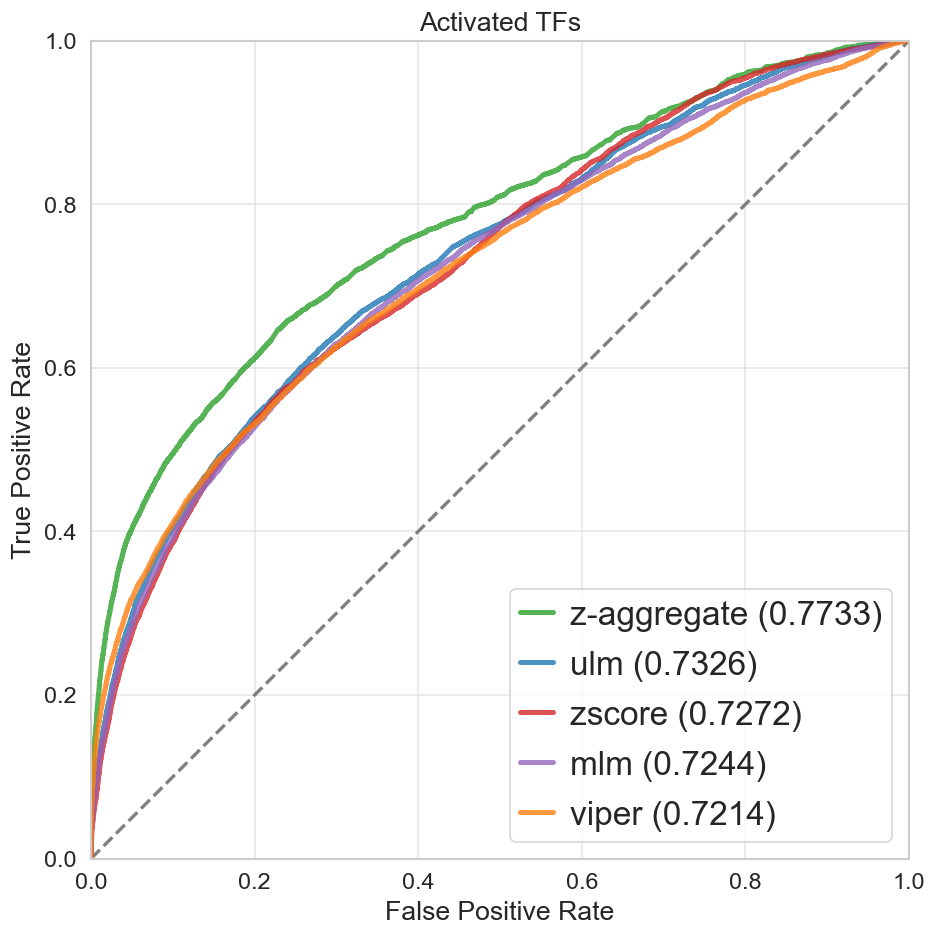

Saved to illustrations/exp1/sim_roc_noisy_tf-factor=3_miss=75.0_noise=0.0_sigma=2_inhibited.svg


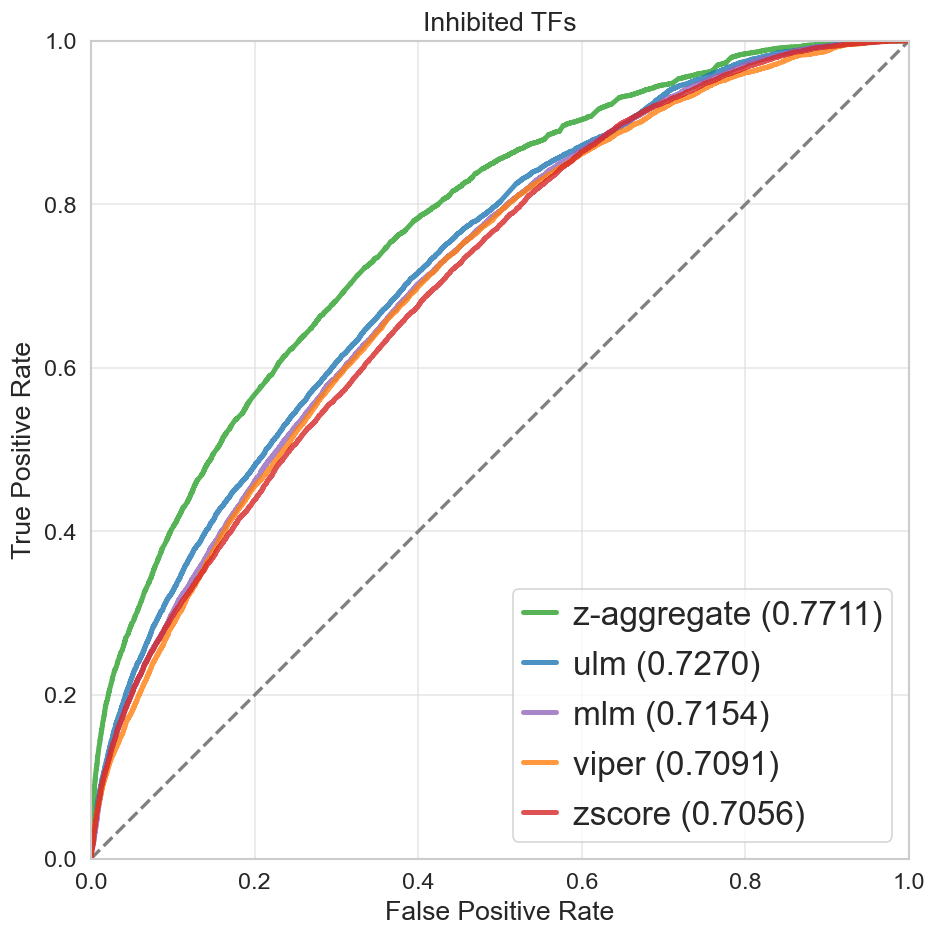

Prior noise: 20.00% | requested edges: 260 | replaced edges: 260
Generating gene expression data...
Zero percentage before explicit dropout: 39.94%
Target zero percentage: 75.00%
Zero percentage after dropout: 75.00%
All files saved to: simulated_data/
Saved to illustrations/exp1/sim_roc_noisy_tf-factor=3_miss=75.0_noise=20.0_sigma=2_activated.svg


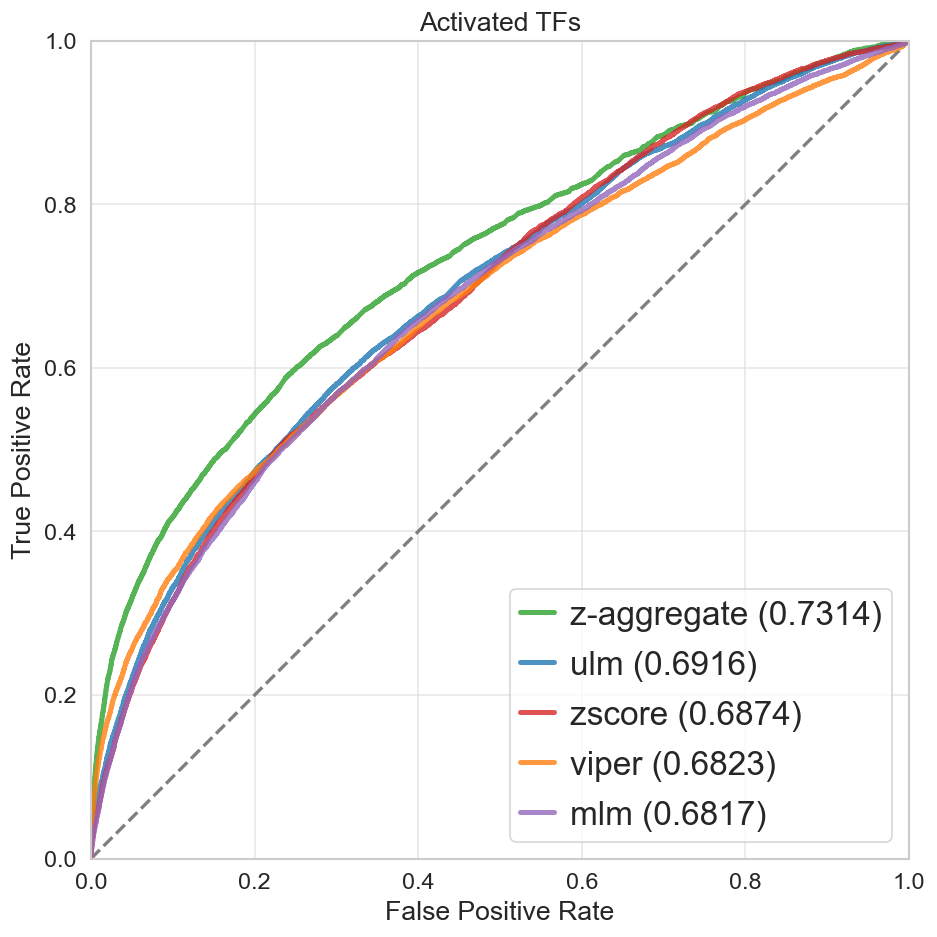

Saved to illustrations/exp1/sim_roc_noisy_tf-factor=3_miss=75.0_noise=20.0_sigma=2_inhibited.svg


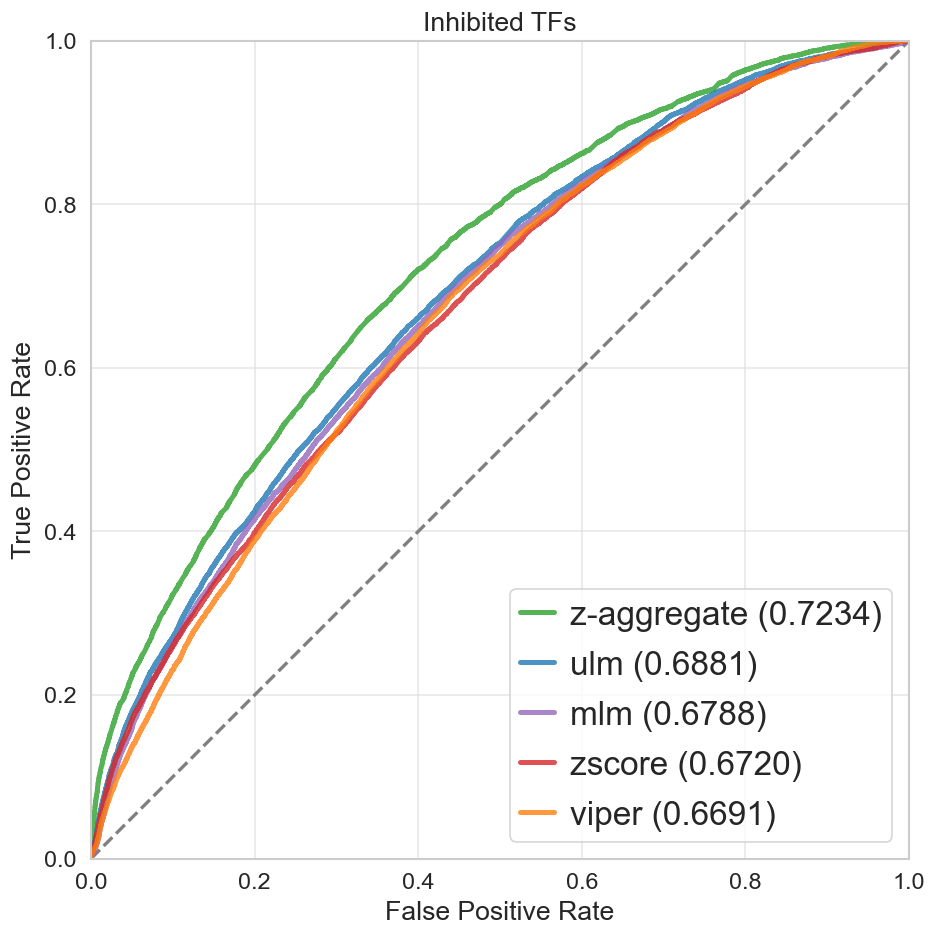

Prior noise: 40.00% | requested edges: 520 | replaced edges: 520
Generating gene expression data...
Zero percentage before explicit dropout: 39.94%
Target zero percentage: 75.00%
Zero percentage after dropout: 75.00%
All files saved to: simulated_data/
Saved to illustrations/exp1/sim_roc_noisy_tf-factor=3_miss=75.0_noise=40.0_sigma=2_activated.svg


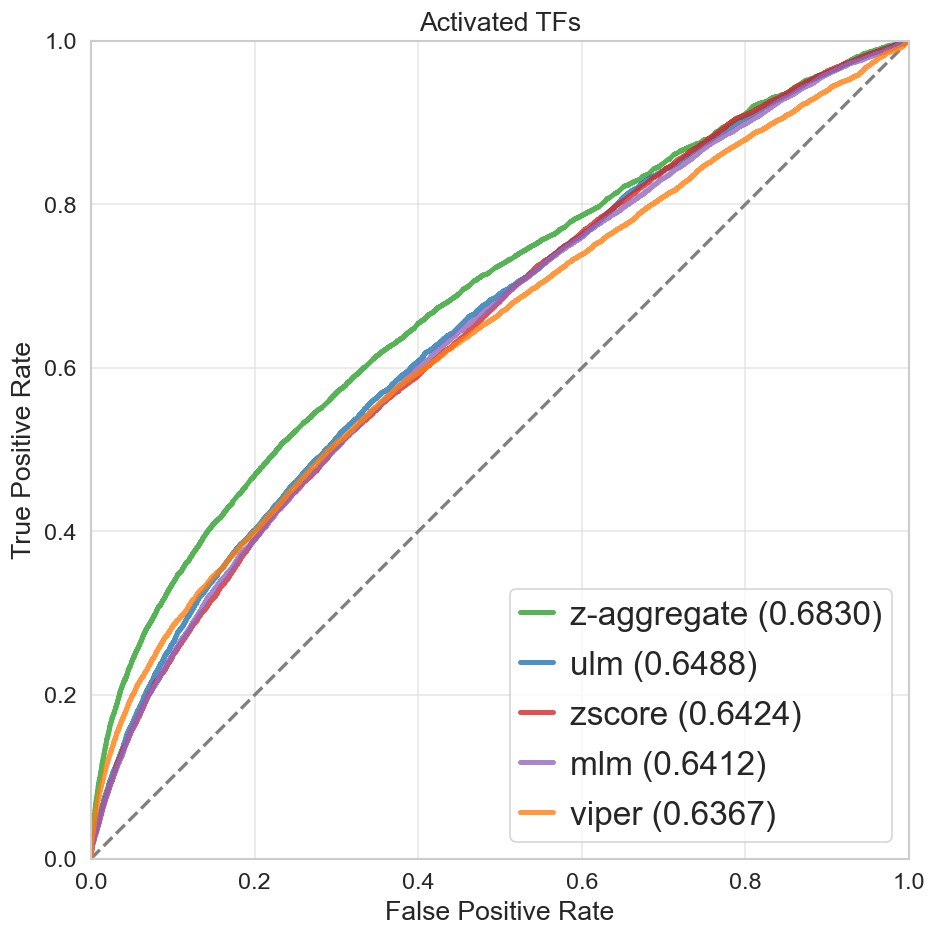

Saved to illustrations/exp1/sim_roc_noisy_tf-factor=3_miss=75.0_noise=40.0_sigma=2_inhibited.svg


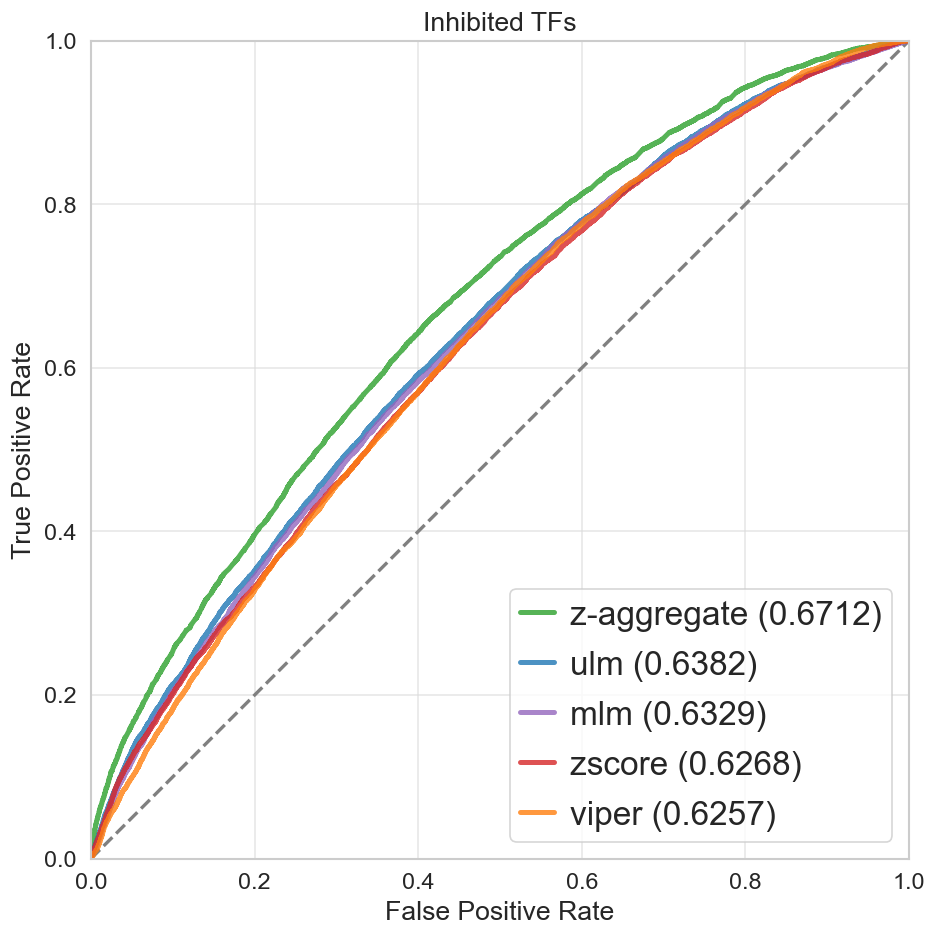

Prior noise: 0.00% | replaced edges: 0
Generating gene expression data...
Zero percentage before explicit dropout: 38.42%
Target zero percentage: 60.00%
Zero percentage after dropout: 60.00%
All files saved to: simulated_data/
Saved to illustrations/exp2/sim_roc_tf-factor=2_miss=60.0_noise=0.0_sigma=2_activated.svg


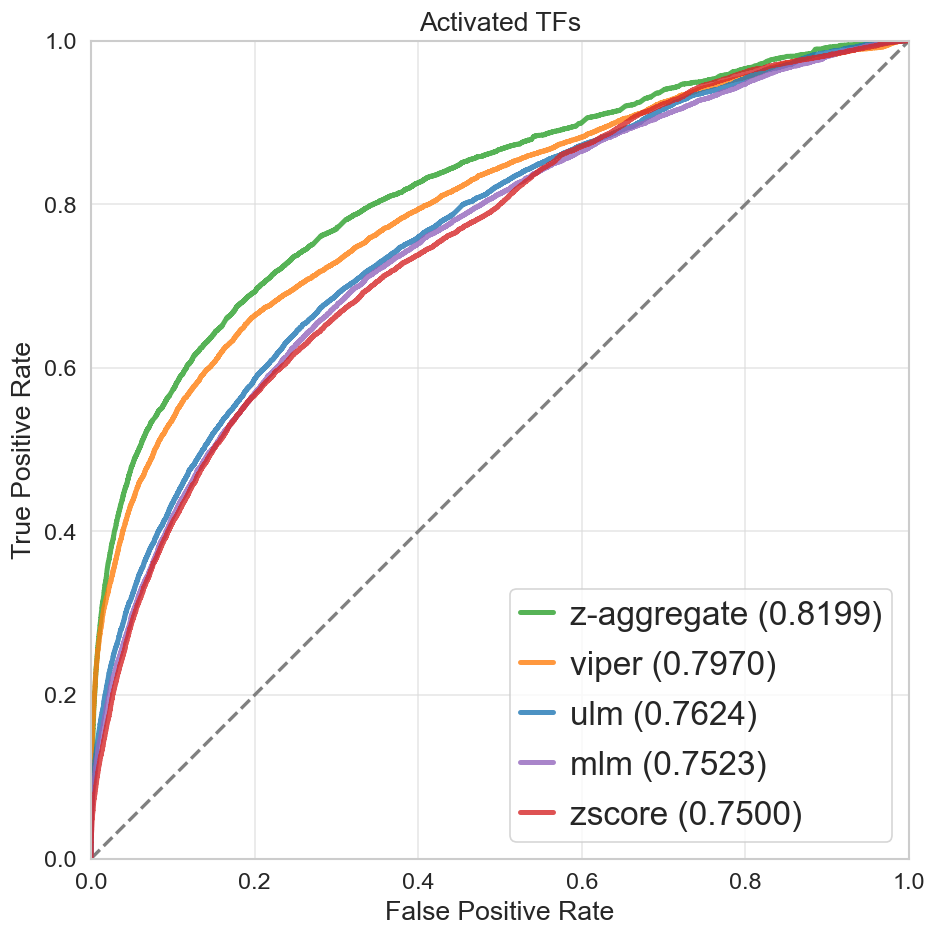

Saved to illustrations/exp2/sim_roc_tf-factor=2_miss=60.0_noise=0.0_sigma=2_inhibited.svg


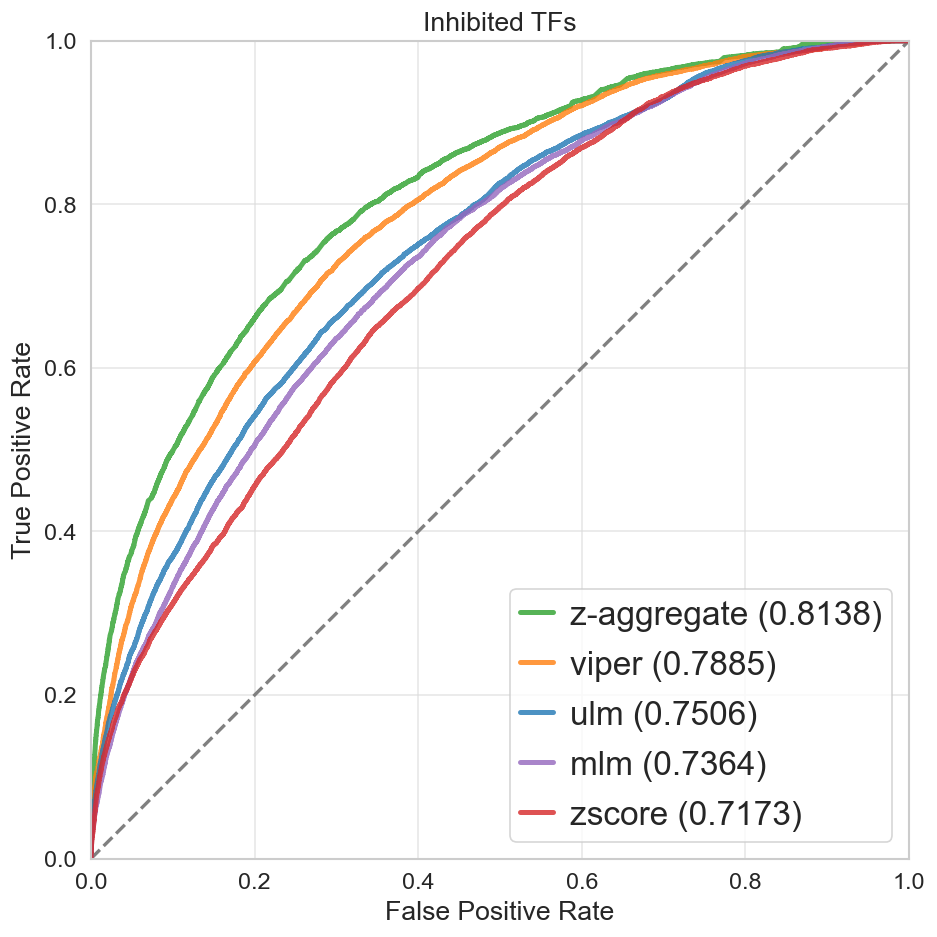

Prior noise: 0.00% | replaced edges: 0
Generating gene expression data...
Zero percentage before explicit dropout: 38.42%
Target zero percentage: 75.00%
Zero percentage after dropout: 75.00%
All files saved to: simulated_data/
Saved to illustrations/exp2/sim_roc_tf-factor=2_miss=75.0_noise=0.0_sigma=2_activated.svg


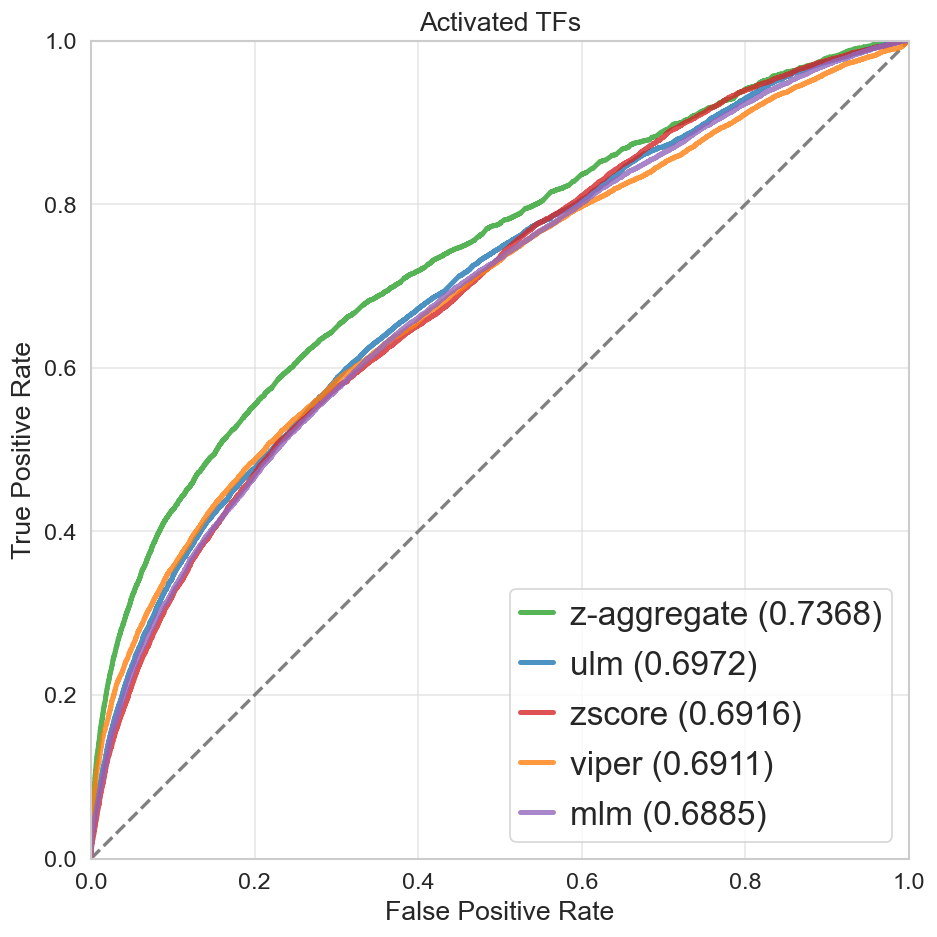

Saved to illustrations/exp2/sim_roc_tf-factor=2_miss=75.0_noise=0.0_sigma=2_inhibited.svg


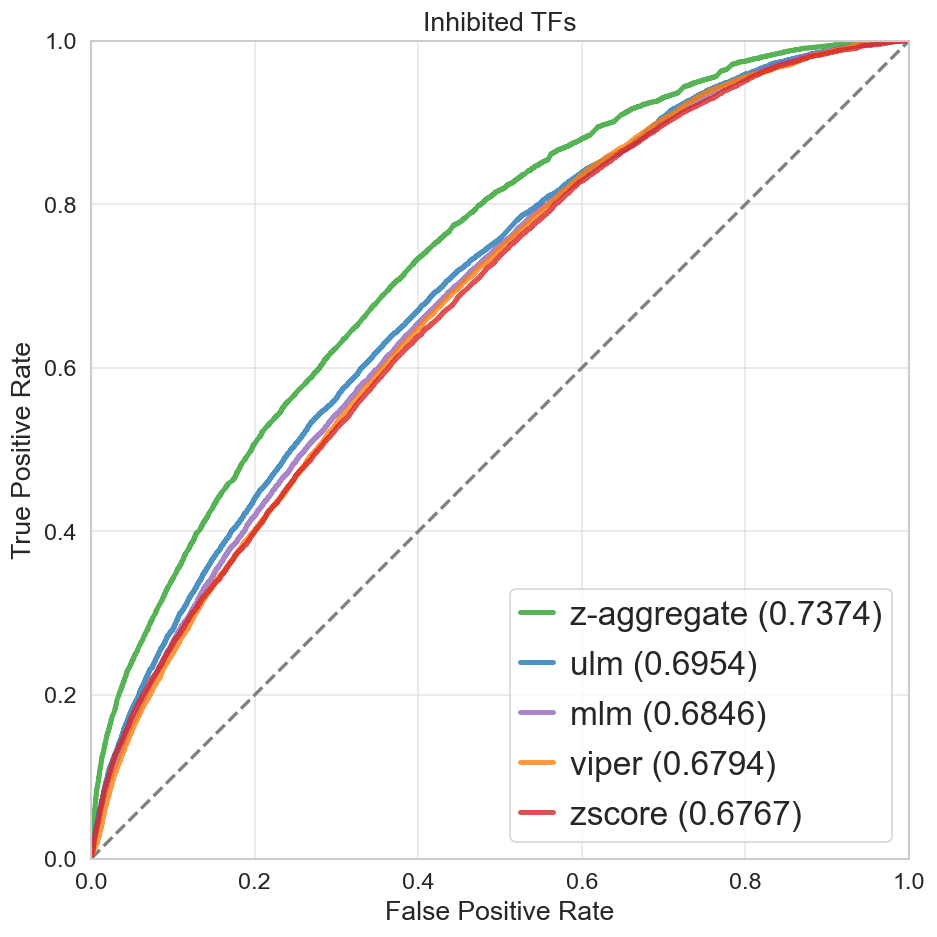

Prior noise: 0.00% | replaced edges: 0
Generating gene expression data...
Zero percentage before explicit dropout: 38.42%
Target zero percentage: 90.00%
Zero percentage after dropout: 90.00%
All files saved to: simulated_data/
Saved to illustrations/exp2/sim_roc_tf-factor=2_miss=90.0_noise=0.0_sigma=2_activated.svg


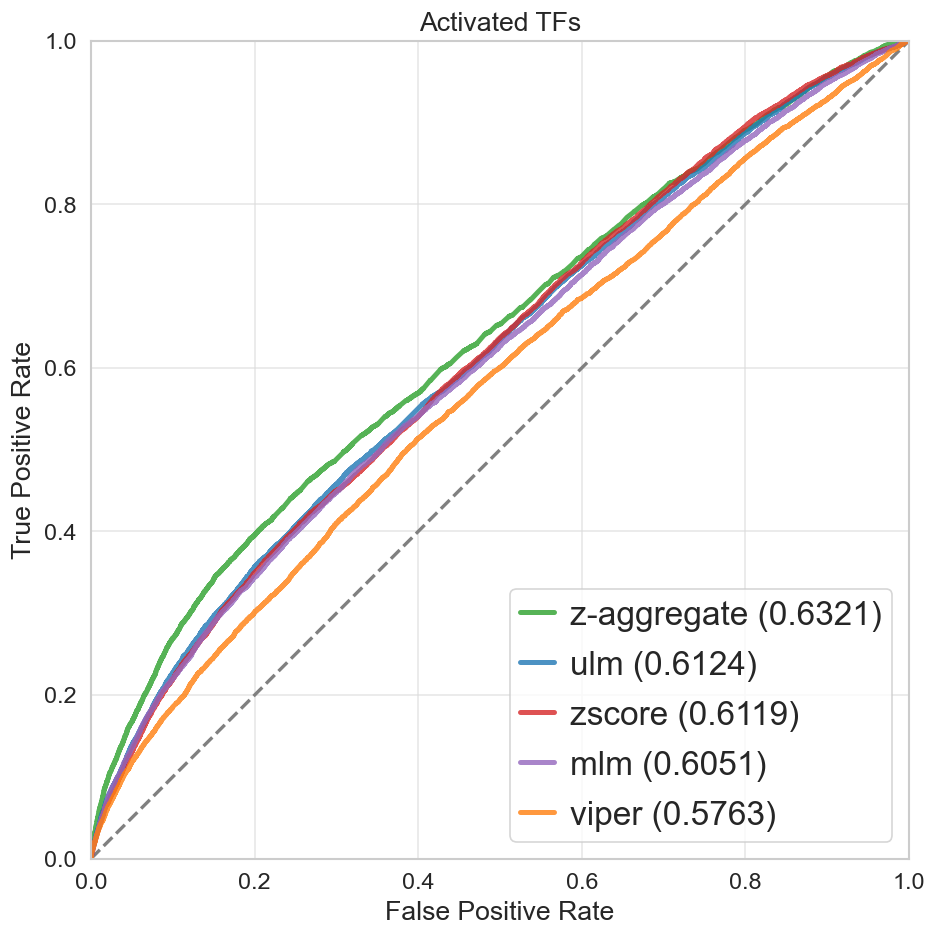

Saved to illustrations/exp2/sim_roc_tf-factor=2_miss=90.0_noise=0.0_sigma=2_inhibited.svg


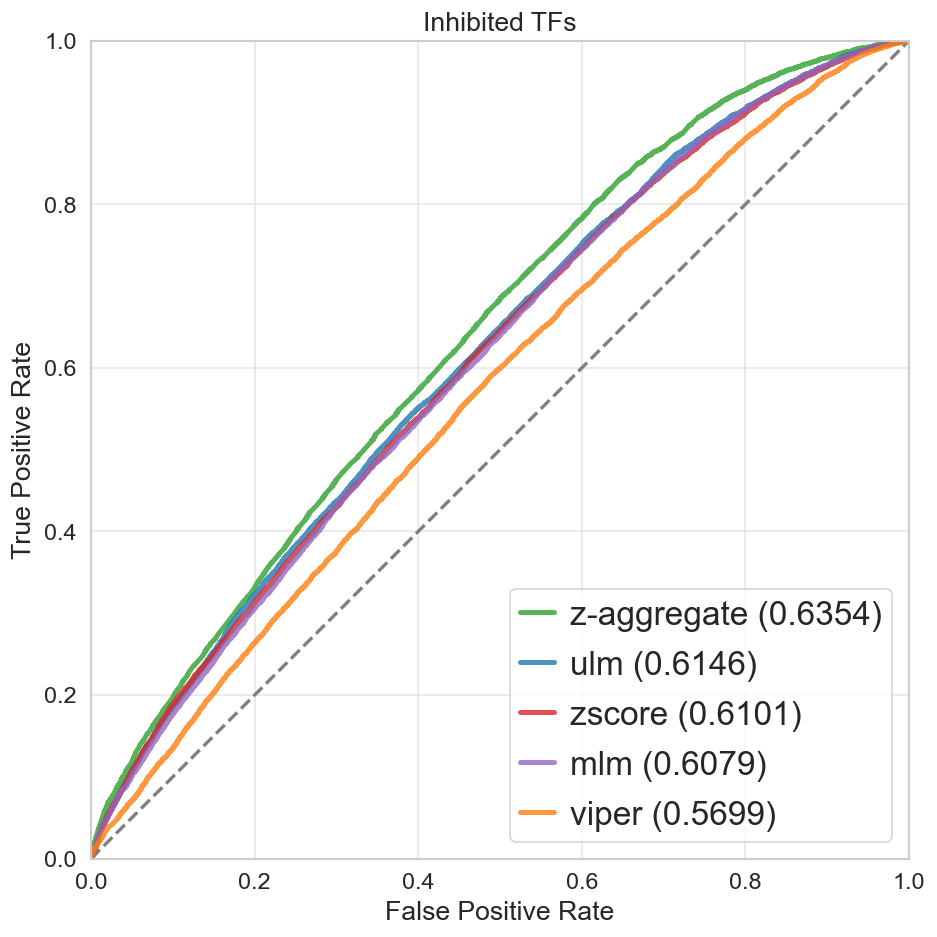

Prior noise: 0.00% | replaced edges: 0
Generating gene expression data...
Zero percentage before explicit dropout: 10.44%
Target zero percentage: 75.00%
Zero percentage after dropout: 75.00%
All files saved to: simulated_data/
Saved to illustrations/exp3/sim_roc_tf-factor=2_miss=75.0_noise=0.0_sigma=1_activated.svg


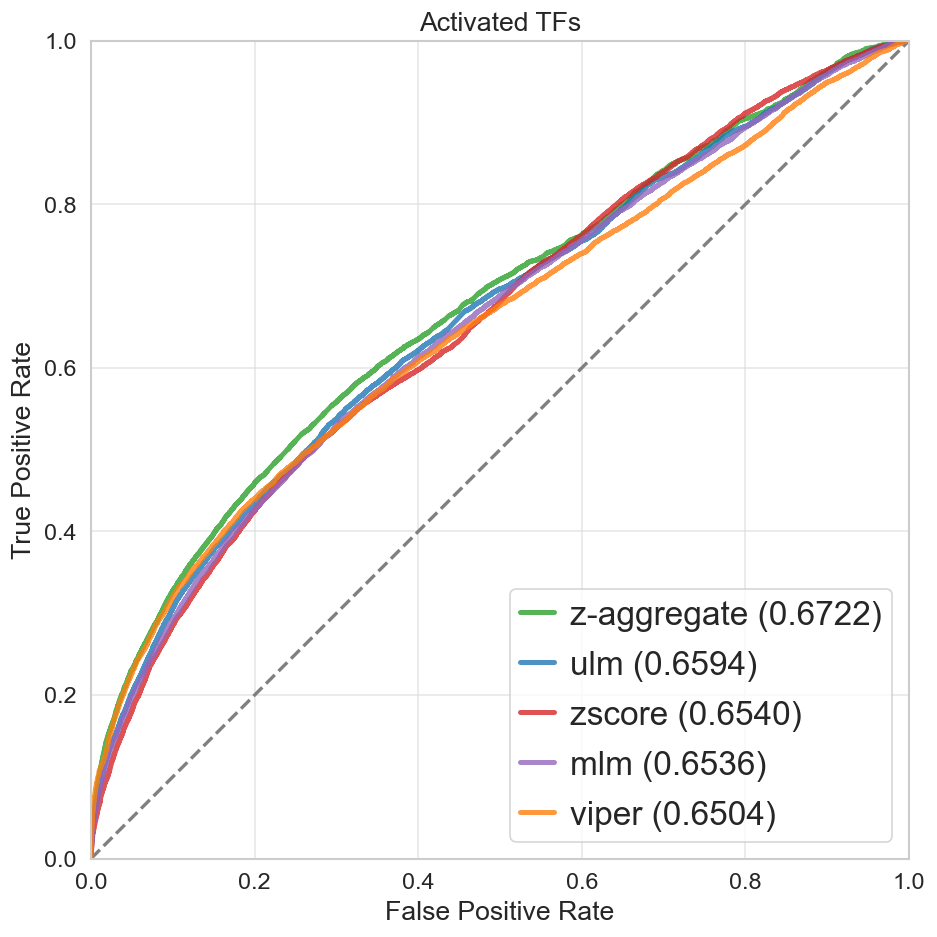

Saved to illustrations/exp3/sim_roc_tf-factor=2_miss=75.0_noise=0.0_sigma=1_inhibited.svg


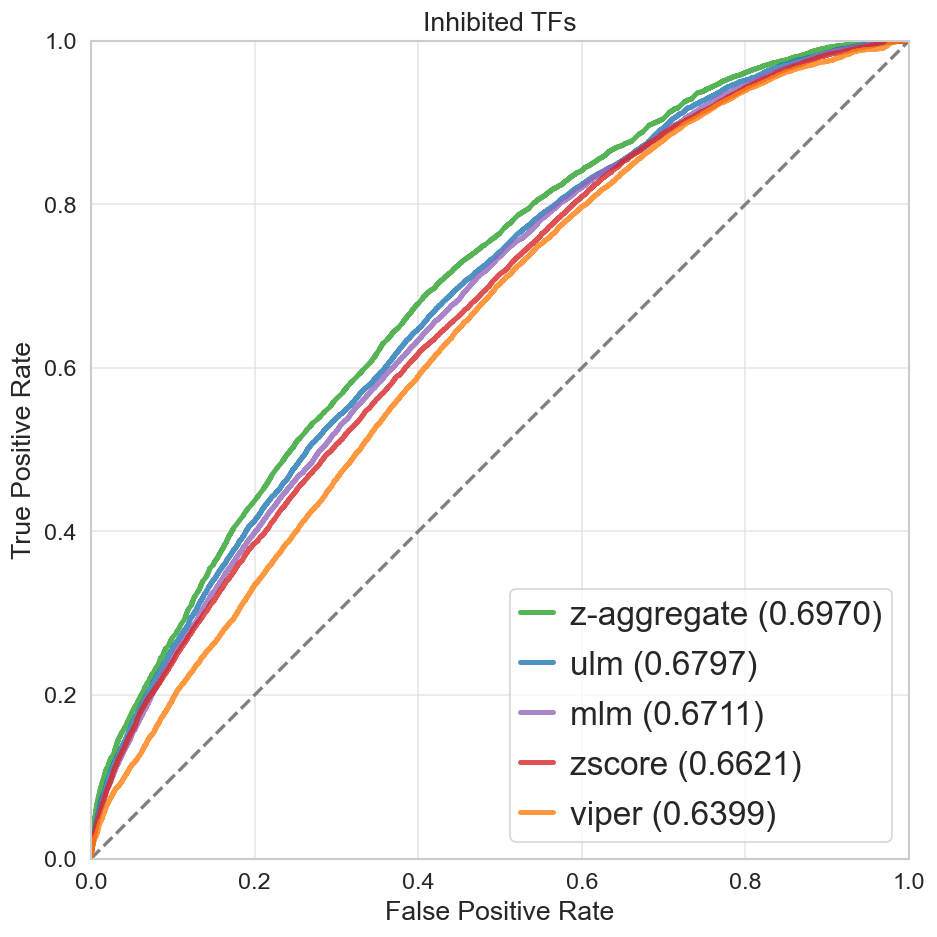

Prior noise: 0.00% | replaced edges: 0
Generating gene expression data...
Zero percentage before explicit dropout: 38.42%
Target zero percentage: 75.00%
Zero percentage after dropout: 75.00%
All files saved to: simulated_data/
Saved to illustrations/exp3/sim_roc_tf-factor=2_miss=75.0_noise=0.0_sigma=2_activated.svg


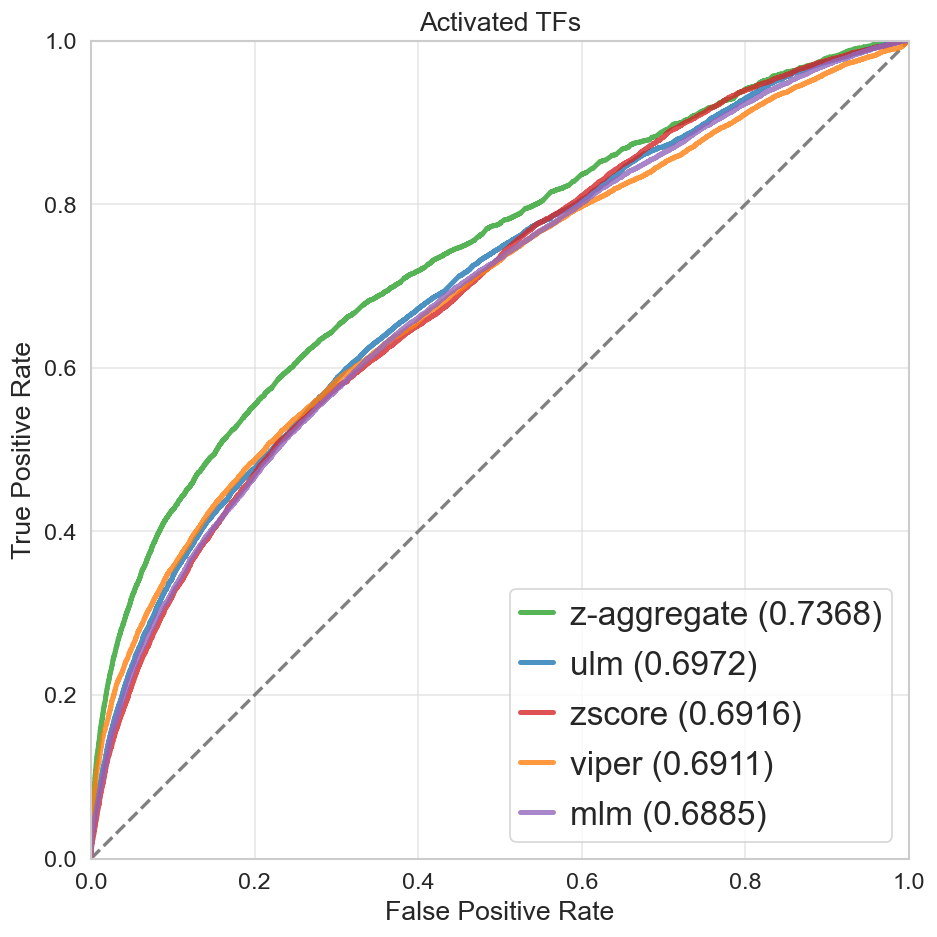

Saved to illustrations/exp3/sim_roc_tf-factor=2_miss=75.0_noise=0.0_sigma=2_inhibited.svg


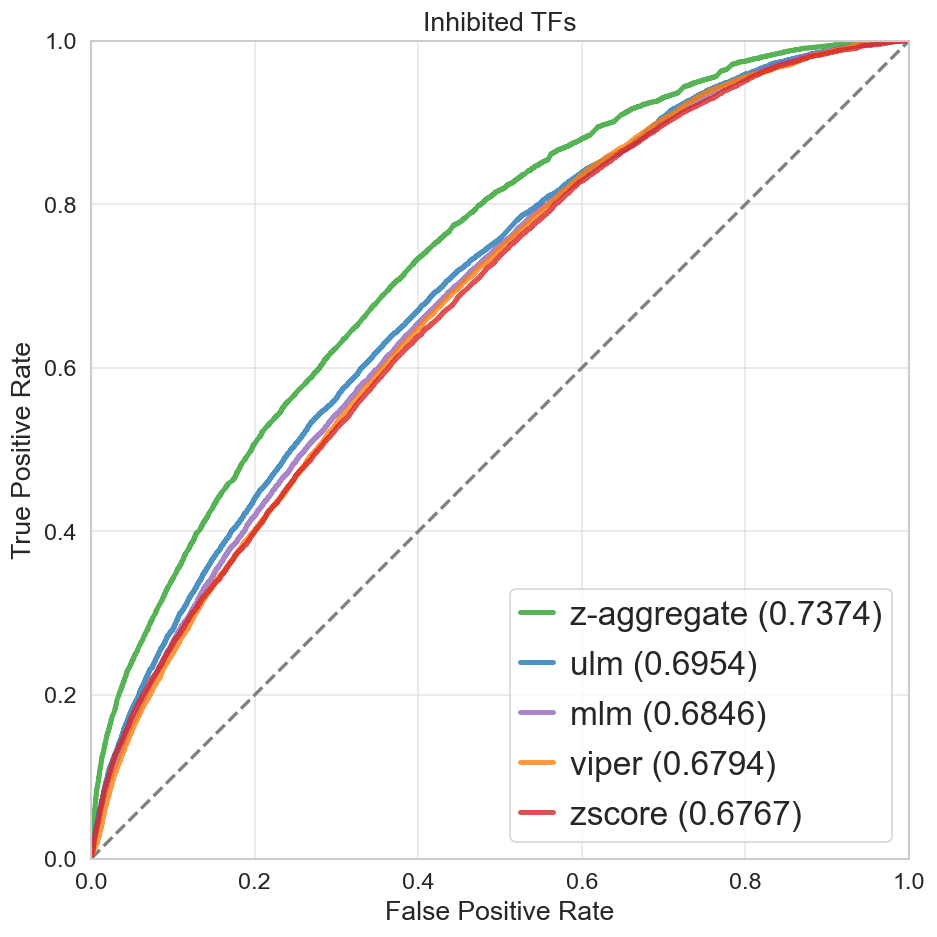

Prior noise: 0.00% | replaced edges: 0
Generating gene expression data...
Zero percentage before explicit dropout: 67.11%
Target zero percentage: 75.00%
Zero percentage after dropout: 75.00%
All files saved to: simulated_data/
Saved to illustrations/exp3/sim_roc_tf-factor=2_miss=75.0_noise=0.0_sigma=3_activated.svg


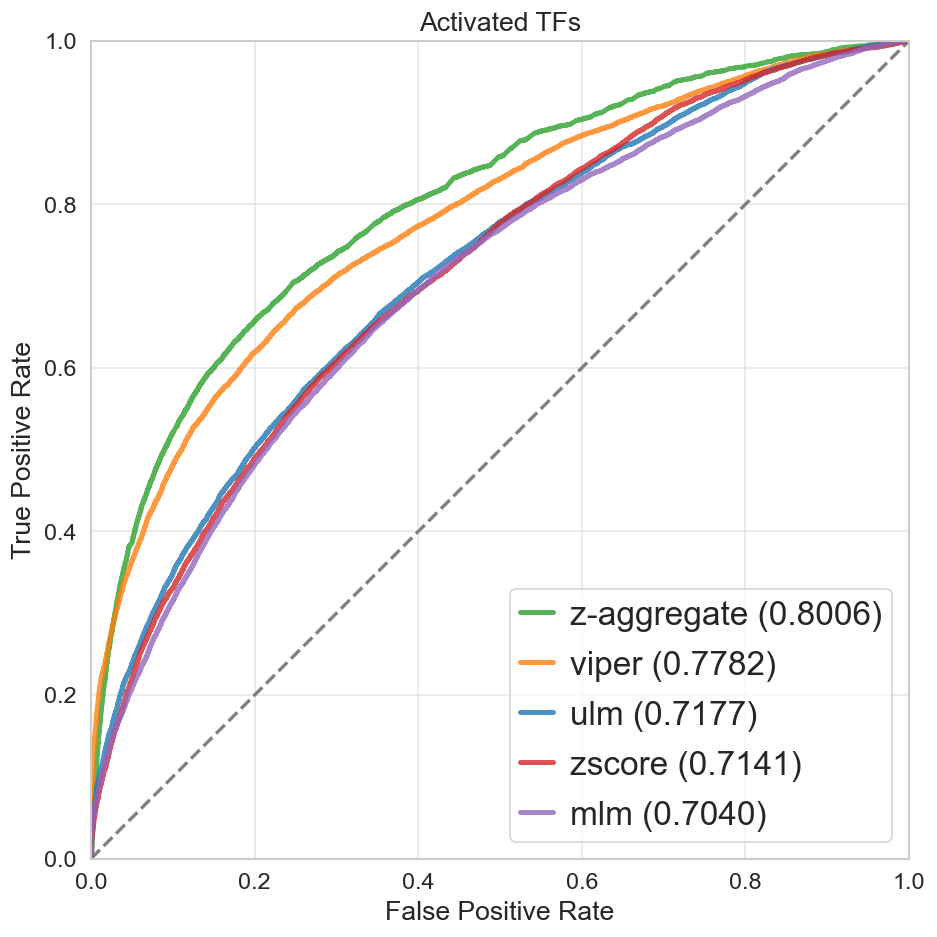

Saved to illustrations/exp3/sim_roc_tf-factor=2_miss=75.0_noise=0.0_sigma=3_inhibited.svg


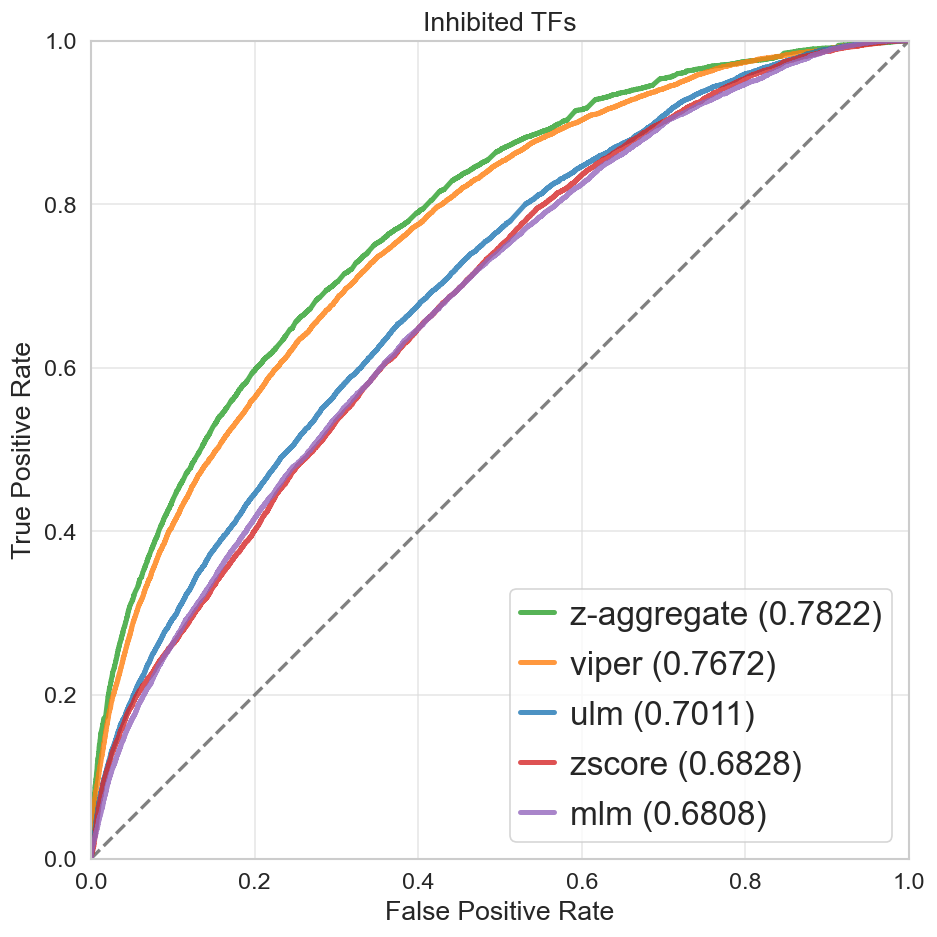

In [33]:
# Note: Default parameters:
# missing_percentage = "75"
# prior_noise_percentage = "0"
# gene_propensity_sigma = "2.0"
# tf_factor_effect = 2 for exp2 and exp3, tf_factor_effect = 3 for exp1


# Experiment 1: Prior Noise Effect
# tf_factor_effect = 3, missing_percentage = "75", gene_propensity_sigma = "2.0"
# Varying prior noise percentage: ["0", 20, 40]
plot_simulated_benchmark(
    params={
        "output_dir": "simulated_data/",
        "output_exp_file": "simulated_scRNASeq.tsv",
        "output_prior_file": "simulated_prior_network.tsv",
        "output_noisy_prior_file": "simulated_noisy_prior_network.tsv",
        "output_ground_truth_file": "simulated_ground_truth.tsv",
        "n_cells": 1000,
        "n_genes": 1000,
        "n_tfs": 100,
        "target_libsize": 1e4,
        "ground_truth_active_inactive_prob": 0.1,
        "up_probability": 0.90,
        "random_seed": 42,
        "tf_effect_factor": 3,
        "missing_percentage": 75.0,
        "prior_noise_percentage": 0.0,
        "gene_propensity_sigma": 2.0,
        "plot_output_dir": "illustrations/exp1",
    },
    is_noisy_prior=True,
    save_plot=True,
)

plot_simulated_benchmark(
    params={
        "output_dir": "simulated_data/",
        "output_exp_file": "simulated_scRNASeq.tsv",
        "output_prior_file": "simulated_prior_network.tsv",
        "output_noisy_prior_file": "simulated_noisy_prior_network.tsv",
        "output_ground_truth_file": "simulated_ground_truth.tsv",
        "n_cells": 1000,
        "n_genes": 1000,
        "n_tfs": 100,
        "target_libsize": 1e4,
        "ground_truth_active_inactive_prob": 0.1,
        "up_probability": 0.90,
        "random_seed": 42,
        "tf_effect_factor": 3,
        "missing_percentage": 75.0,
        "prior_noise_percentage": 20.0,
        "gene_propensity_sigma": 2.0,
        "plot_output_dir": "illustrations/exp1",
    },
    is_noisy_prior=True,
    save_plot=True,
)

plot_simulated_benchmark(
    params={
        "output_dir": "simulated_data/",
        "output_exp_file": "simulated_scRNASeq.tsv",
        "output_prior_file": "simulated_prior_network.tsv",
        "output_noisy_prior_file": "simulated_noisy_prior_network.tsv",
        "output_ground_truth_file": "simulated_ground_truth.tsv",
        "n_cells": 1000,
        "n_genes": 1000,
        "n_tfs": 100,
        "target_libsize": 1e4,
        "ground_truth_active_inactive_prob": 0.1,
        "up_probability": 0.90,
        "random_seed": 42,
        "tf_effect_factor": 3,
        "missing_percentage": 75.0,
        "prior_noise_percentage": 40.0,
        "gene_propensity_sigma": 2.0,
        "plot_output_dir": "illustrations/exp1",
    },
    is_noisy_prior=True,
    save_plot=True,
)


# Experiment 2: Missing Percentage Effect
# tf_factor_effect = 2, prior_noise_percentage = "0", gene_propensity_sigma = "2.0"
# Varying missing percentage: [60, "75", 90]
plot_simulated_benchmark(
    params={
        "output_dir": "simulated_data/",
        "output_exp_file": "simulated_scRNASeq.tsv",
        "output_prior_file": "simulated_prior_network.tsv",
        "output_noisy_prior_file": "simulated_noisy_prior_network.tsv",
        "output_ground_truth_file": "simulated_ground_truth.tsv",
        "n_cells": 1000,
        "n_genes": 1000,
        "n_tfs": 100,
        "target_libsize": 1e4,
        "ground_truth_active_inactive_prob": 0.1,
        "up_probability": 0.90,
        "random_seed": 42,
        "tf_effect_factor": 2,
        "missing_percentage": 60.0,
        "prior_noise_percentage": 0.0,
        "gene_propensity_sigma": 2.0,
        "plot_output_dir": "illustrations/exp2",
    },
    is_noisy_prior=False,
    save_plot=True,
)

plot_simulated_benchmark(
    params={
        "output_dir": "simulated_data/",
        "output_exp_file": "simulated_scRNASeq.tsv",
        "output_prior_file": "simulated_prior_network.tsv",
        "output_noisy_prior_file": "simulated_noisy_prior_network.tsv",
        "output_ground_truth_file": "simulated_ground_truth.tsv",
        "n_cells": 1000,
        "n_genes": 1000,
        "n_tfs": 100,
        "target_libsize": 1e4,
        "ground_truth_active_inactive_prob": 0.1,
        "up_probability": 0.90,
        "random_seed": 42,
        "tf_effect_factor": 2,
        "missing_percentage": 75.0,
        "prior_noise_percentage": 0.0,
        "gene_propensity_sigma": 2.0,
        "plot_output_dir": "illustrations/exp2",
    },
    is_noisy_prior=False,
    save_plot=True,
)

plot_simulated_benchmark(
    params={
        "output_dir": "simulated_data/",
        "output_exp_file": "simulated_scRNASeq.tsv",
        "output_prior_file": "simulated_prior_network.tsv",
        "output_noisy_prior_file": "simulated_noisy_prior_network.tsv",
        "output_ground_truth_file": "simulated_ground_truth.tsv",
        "n_cells": 1000,
        "n_genes": 1000,
        "n_tfs": 100,
        "target_libsize": 1e4,
        "ground_truth_active_inactive_prob": 0.1,
        "up_probability": 0.90,
        "random_seed": 42,
        "tf_effect_factor": 2,
        "missing_percentage": 90.0,
        "prior_noise_percentage": 0.0,
        "gene_propensity_sigma": 2.0,
        "plot_output_dir": "illustrations/exp2",
    },
    is_noisy_prior=False,
    save_plot=True,
)


# Experiment 3: Gene Propensity Sigma Effect
# tf_factor_effect = 2, prior_noise_percentage = "0", missing_percentage = "75"
# Varying gene_propensity_sigma: [1.0, "2.0", 3.0]
plot_simulated_benchmark(
    params={
        "output_dir": "simulated_data/",
        "output_exp_file": "simulated_scRNASeq.tsv",
        "output_prior_file": "simulated_prior_network.tsv",
        "output_noisy_prior_file": "simulated_noisy_prior_network.tsv",
        "output_ground_truth_file": "simulated_ground_truth.tsv",
        "n_cells": 1000,
        "n_genes": 1000,
        "n_tfs": 100,
        "target_libsize": 1e4,
        "ground_truth_active_inactive_prob": 0.1,
        "up_probability": 0.90,
        "random_seed": 42,
        "tf_effect_factor": 2,
        "missing_percentage": 75.0,
        "prior_noise_percentage": 0.0,
        "gene_propensity_sigma": 1.0,
        "plot_output_dir": "illustrations/exp3",
    },
    is_noisy_prior=False,
    save_plot=True,
)

plot_simulated_benchmark(
    params={
        "output_dir": "simulated_data/",
        "output_exp_file": "simulated_scRNASeq.tsv",
        "output_prior_file": "simulated_prior_network.tsv",
        "output_noisy_prior_file": "simulated_noisy_prior_network.tsv",
        "output_ground_truth_file": "simulated_ground_truth.tsv",
        "n_cells": 1000,
        "n_genes": 1000,
        "n_tfs": 100,
        "target_libsize": 1e4,
        "ground_truth_active_inactive_prob": 0.1,
        "up_probability": 0.90,
        "random_seed": 42,
        "tf_effect_factor": 2,
        "missing_percentage": 75.0,
        "prior_noise_percentage": 0.0,
        "gene_propensity_sigma": 2.0,
        "plot_output_dir": "illustrations/exp3",
    },
    is_noisy_prior=False,
    save_plot=True,
)

plot_simulated_benchmark(
    params={
        "output_dir": "simulated_data/",
        "output_exp_file": "simulated_scRNASeq.tsv",
        "output_prior_file": "simulated_prior_network.tsv",
        "output_noisy_prior_file": "simulated_noisy_prior_network.tsv",
        "output_ground_truth_file": "simulated_ground_truth.tsv",
        "n_cells": 1000,
        "n_genes": 1000,
        "n_tfs": 100,
        "target_libsize": 1e4,
        "ground_truth_active_inactive_prob": 0.1,
        "up_probability": 0.90,
        "random_seed": 42,
        "tf_effect_factor": 2,
        "missing_percentage": 75.0,
        "prior_noise_percentage": 0.0,
        "gene_propensity_sigma": 3.0,
        "plot_output_dir": "illustrations/exp3",
    },
    is_noisy_prior=False,
    save_plot=True,
)

Simulated priors target count distribution. 
Simulating a heavy-tailed distribution (log-normal) for TF target counts. 
This is a common choice for modeling biological networks, 
where most TFs regulate few targets and a few TFs regulate many targets.

Number of TFs: 100
Number of edges: 1301
Mean targets per TF: 13.0100
Median targets per TF: 7.5000
Min targets per TF: 1
Max targets per TF: 184

Fitted log-normal mu: 1.9504
Fitted log-normal sigma: 1.1208


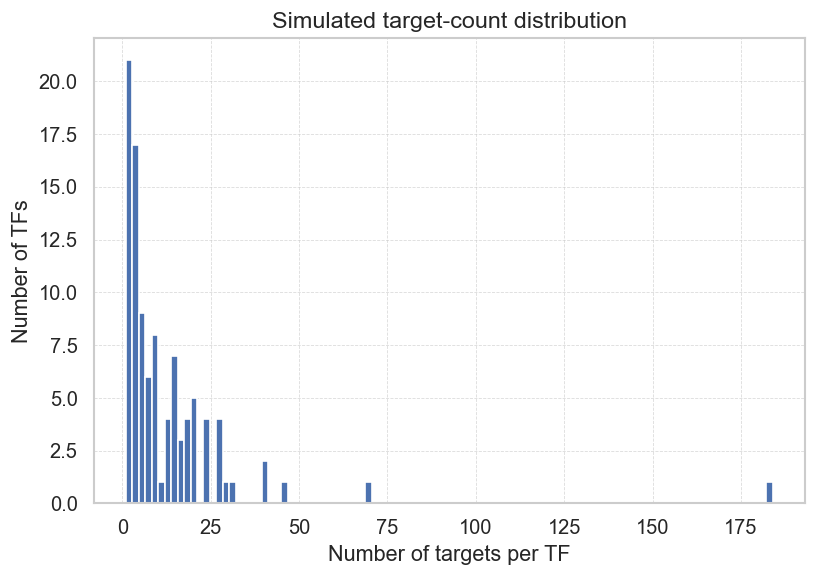

In [34]:
# Plot distribution
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load prior
print(f"""Simulated priors target count distribution. 
Simulating a heavy-tailed distribution (log-normal) for TF target counts. 
This is a common choice for modeling biological networks, 
where most TFs regulate few targets and a few TFs regulate many targets.\n""")

prior_path = "simulated_data/simulated_prior_network.tsv"
prior = pd.read_csv(prior_path, sep="\t")

# Basic cleanup
prior = prior[["source", "interaction", "target"]].dropna()
prior["source"] = prior["source"].astype(str).str.strip()
prior["target"] = prior["target"].astype(str).str.strip()

# Count total targets per TF
target_counts = (
    prior.drop_duplicates(["source", "target"])
    .groupby("source")
    .size()
    .rename("n_targets")
)

# Fit log-normal parameters
# If X ~ LogNormal(mu, sigma), then log(X) ~ Normal(mu, sigma)
log_counts = np.log(target_counts.values)

mu = log_counts.mean()
sigma = log_counts.std(ddof=1)

print(f"Number of TFs: {target_counts.shape[0]}")
print(f"Number of edges: {len(prior):}")
print(f"Mean targets per TF: {target_counts.mean():.4f}")
print(f"Median targets per TF: {target_counts.median():.4f}")
print(f"Min targets per TF: {target_counts.min()}")
print(f"Max targets per TF: {target_counts.max()}")
print()
print(f"Fitted log-normal mu: {mu:.4f}")
print(f"Fitted log-normal sigma: {sigma:.4f}")

# Plot raw heavy-tail distribution
plt.figure(figsize=(7, 5))
plt.hist(target_counts, bins=100)
plt.xlabel("Number of targets per TF")
plt.ylabel("Number of TFs")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.title("Simulated target-count distribution")
plt.tight_layout()
plt.show()